In [1]:
from backend.utils.gmsh_function import *
from backend.utils.file_path import *
from backend.src.radiation_algorithm.radiation_algorithm import *
from nice_cube_gmsh import *

from backend.efield.efield1 import *
from backend.efield.efield2 import radiation_intensity_distribution_over_sphere_surface
from backend.efield.efield3 import antenna_directivity_pattern

from backend.utils.frequency_sweep import *

## This code create a 3D version of the nice Cubesat

In [2]:
name = "Nice_Cube"
path = setup_save_file_paths(name)

In [3]:
# Coding the Nice CubeSat geometry
cm = 1e-2 # 1 cm
C = 10 * cm

mm = 1e-3 # 1 mm

initial_mesh_size = 5 * cm

space_btw_cubesat_and_solar_panel = 0.4 * cm

length_of_connection_between_cubesat_and_solar_panel = 1.5 * cm

gmsh.initialize()

gmsh.model.add("CubeSat")

setup_performance_config()

create_nice_cube_geometry(C, space_btw_cubesat_and_solar_panel, length_of_connection_between_cubesat_and_solar_panel)

generate_and_save_mesh(path.geo, path.msh, initial_mesh_size)

# gmsh.fltk.run()

gmsh.finalize()

[PERFORMANCE] Gmsh configured to utilize 16 threads.
Geometry file saved in data/gmsh_files/Nice_Cube.brep successfully
--- Starting Mesh Optimization (Dim: 2) ---
--- Optimization Complete ---
Mesh file saved in data/gmsh_files/Nice_Cube.msh successfully


In [4]:
feed_point = np.array([
    [C/2 + space_btw_cubesat_and_solar_panel, C/2 - length_of_connection_between_cubesat_and_solar_panel/2, 0],
    [-C/2 + length_of_connection_between_cubesat_and_solar_panel/2, C/2 + space_btw_cubesat_and_solar_panel, 0],
    [-C/2 - space_btw_cubesat_and_solar_panel, -C/2 + length_of_connection_between_cubesat_and_solar_panel/2, 0],
    [C/2 - length_of_connection_between_cubesat_and_solar_panel/2, -C/2 - space_btw_cubesat_and_solar_panel, 0]])

# phase for the 4 feed points of the nice cube, we set the phase to 0, 90, 180, and 270 degrees for the 4 feed points respectively
phase = np.array([0, 90, 180, 270]) * np.pi / 180

# voltage amplitude for the 4 feed points of the nice cube, we set the amplitude to 1 for certain feed points and -1 for others to create a specific radiation pattern
voltage_amplitude = [1, 1, -1, -1]

# Exitation units vector for the 4 feed points of the nice cube depending on how the solar panels are oriented
excitation_units_vector = ['x', 'y', 'x', 'y']

light_speed = 3e8
frequency = 440e6

wavelength = light_speed / frequency
print(f"wavelength = {wavelength} Meter")

wavelength = 0.6818181818181818 Meter


In [5]:
_ = radiation_algorithm(path, frequency, feed_point,
                        voltage_amplitude=voltage_amplitude, 
                        excitation_unit_vector=excitation_units_vector, 
                        gap_width=0.054*initial_mesh_size,
                        voltage_phase=phase)

In [6]:
observationPoint = np.array([0, 0, -100])

calculate_electric_magnetic_field_at_point(path, observationPoint)


Frequency = 440000000.0 Hz
Wavelength lambda = 0.6812553499559301 m
The observation point is : [   0    0 -100]

e_field_total of Nice_Cube at the observation point [   0    0 -100] is :
 0.0031743 - 0.0065181i V/m
 0.0064790 + 0.0031544i V/m
-0.0000000 + 0.0000000i V/m

h_field_total of Nice_Cube at the observation point [   0    0 -100] is :
 0.0000172 + 0.0000084i A/m
-0.0000084 + 0.0000173i A/m
-0.0000000 + 0.0000000i A/m

Poynting vector is equal to : 
1.5202251849794433e-14 W/m^2
2.4416908028350285e-14 W/m^2
-1.3865823256947964e-07 W/m^2

w = 1.3865823256948264e-07 W/m^2

u = 0.0013865823256948263 W/unit solid angle


In [7]:
analyze_point_fields_polarization(path, observationPoint)


 ELECTROMAGNETIC ANALYSIS AT POINT: Nice_Cube

[Location]
  Cartesian (X, Y, Z) : (0.000, 0.000, -100.000) m
  Spherical (r, θ, φ) : (100.000 m, 180.00°, 0.00°)

[Cartesian E-Field (V/m)]
  Ex : +3.1743294e-03 -6.5180804e-03j
  Ey : +6.4790070e-03 +3.1543732e-03j
  Ez : -6.8516158e-09 -6.6412533e-09j

[Spherical E-Field (V/m)]
  E_theta : -3.1743294e-03 +6.5180804e-03j  (|E| = 7.24995e-03)
  E_phi   : +6.4790070e-03 +3.1543732e-03j  (|E| = 7.20608e-03)

[Circular Polarization]
  E_RHCP  : -4.4750685e-03 +9.1903286e-03j  (|E| = 1.02220e-02)
  E_LHCP  : -1.4111185e-05 +2.7629073e-05j  (|E| = 3.10240e-05)
  Axial Ratio : 1.0061 (0.05 dB)
  Detected Polarization Type: **CIRCULAR**

[Power Metrics]
  Poynting (Px, Py, Pz) : (1.52e-14, 2.44e-14, -1.39e-07) W/m²
  Intensity (u)         : 1.38658e-03 W/sr




In [8]:
print("Calculating radiation intensity distribution over sphere surface...")
radiation_intensity_distribution_over_sphere_surface(path)

Calculating radiation intensity distribution over sphere surface...
MODE SELECTED: radiation
Frequency = 4.40e+08 Hz | Wavelength lambda = 0.6813 m

[Antenna Results]
  Total Radiated Power : 0.0063 W
  Max Gain : 2.7613 (4.41 dBi)
  Radiation Resistance : 0.0031 Ohms
  Total Efficiency : 0.63 %
Data saved successfully to data/antennas_gain_power/Nice_Cube_gain_power.mat


Generating antenna directivity pattern...
Data loaded from data/antennas_gain_power/Nice_Cube_gain_power.mat


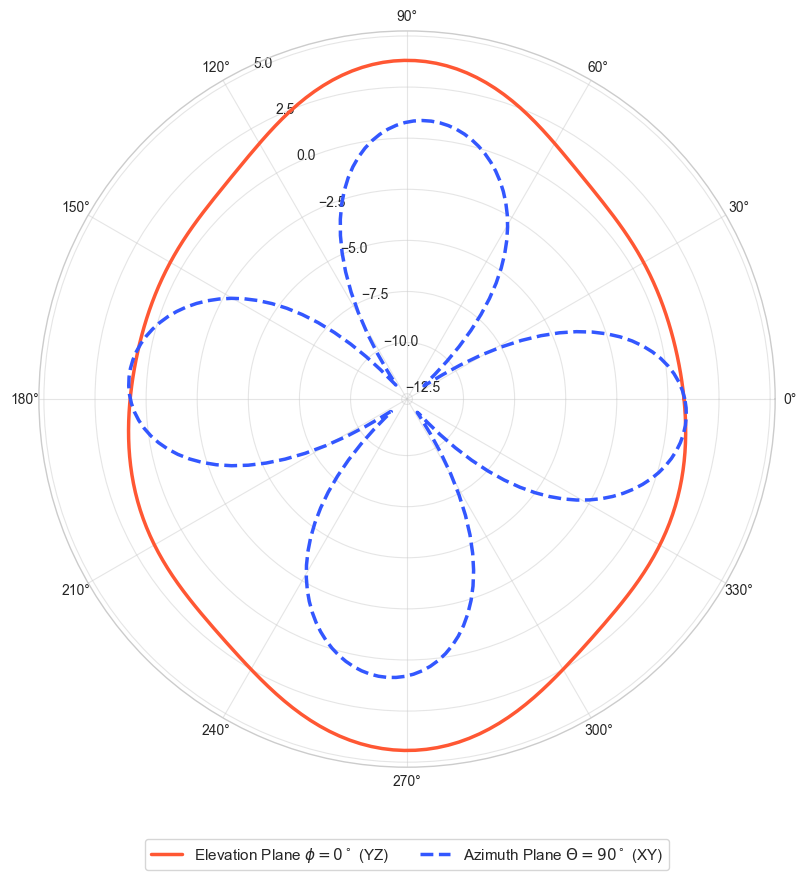

In [9]:
# Step 3: Generating the directivity pattern
print("Generating antenna directivity pattern...")
antenna_directivity_pattern(path, mode='radiation')

In [10]:
freq_start = 400e6
freq_stop  = 500e6
frequency_sweep(path, freq_start, freq_stop, 
                feed_point, excitation_unit_vector=excitation_units_vector, gap_width=0.054*initial_mesh_size, voltage_phase=phase, 
                step=5e6, show=False)

MULTIPLE PORT FREQUENCY SWEEP CONFIGURATION
Number of Ports detected: 4
  > Port 0 | Location: [0.054  0.0425 0.    ] | Phase Offset:   0.00°
  > Port 1 | Location: [-0.0425  0.054   0.    ] | Phase Offset:  90.00°
  > Port 2 | Location: [-0.054  -0.0425  0.    ] | Phase Offset: 180.00°
  > Port 3 | Location: [ 0.0425 -0.054   0.    ] | Phase Offset: 270.00°
Range: 400.00 MHz to 500.00 MHz (21 points)

Step 1/21 |  400.00 MHz | P0: -0.62dB | P1: -0.88dB | P2: -0.65dB | P3: -0.91dB
Step 2/21 |  405.00 MHz | P0: -0.65dB | P1: -0.91dB | P2: -0.68dB | P3: -0.93dB
Step 3/21 |  410.00 MHz | P0: -0.67dB | P1: -0.93dB | P2: -0.71dB | P3: -0.96dB
Step 4/21 |  415.00 MHz | P0: -0.70dB | P1: -0.96dB | P2: -0.74dB | P3: -0.98dB
Step 5/21 |  420.00 MHz | P0: -0.73dB | P1: -0.98dB | P2: -0.76dB | P3: -1.01dB
Step 6/21 |  425.00 MHz | P0: -0.75dB | P1: -1.01dB | P2: -0.79dB | P3: -1.03dB
Step 7/21 |  430.00 MHz | P0: -0.78dB | P1: -1.03dB | P2: -0.82dB | P3: -1.06dB
Step 8/21 |  435.00 MHz | P0: -0.8

Plotting all 4 ports. Note: To view a specific port, use 'port_idx=n'.


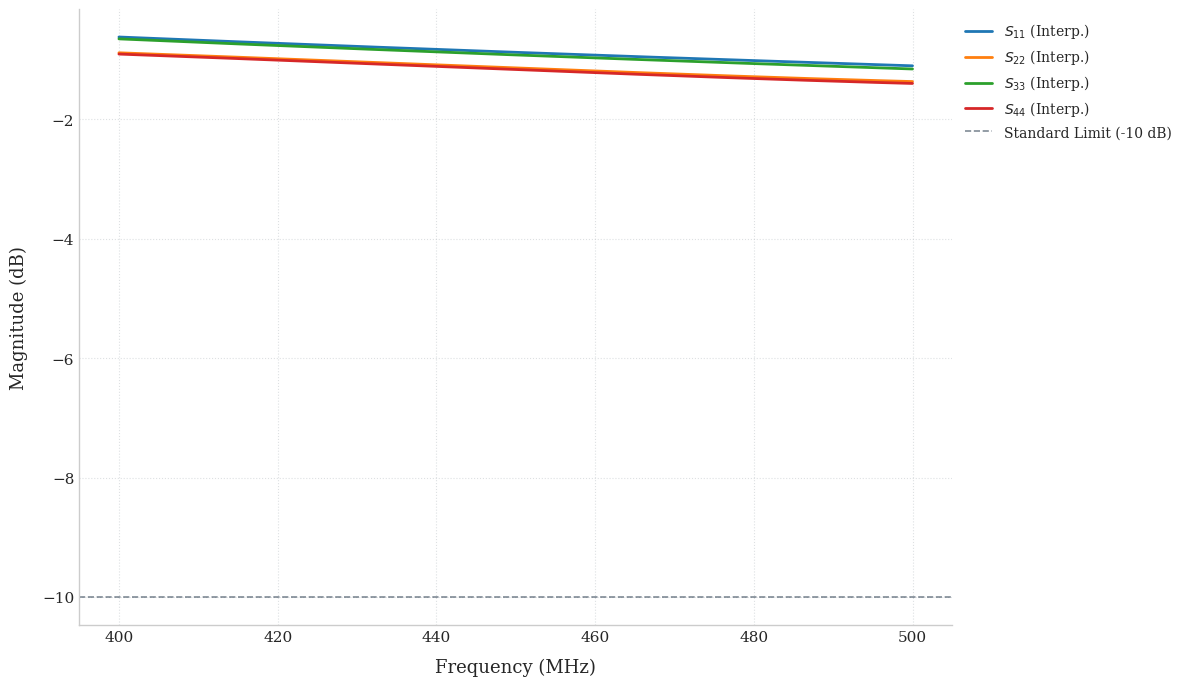

In [11]:
plot_s_parameters(path, interpolation_threshold=0)